In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

In [21]:
df = pd.read_csv("data/car_fuel_efficiency_2026.csv")
df = df.loc[:,['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


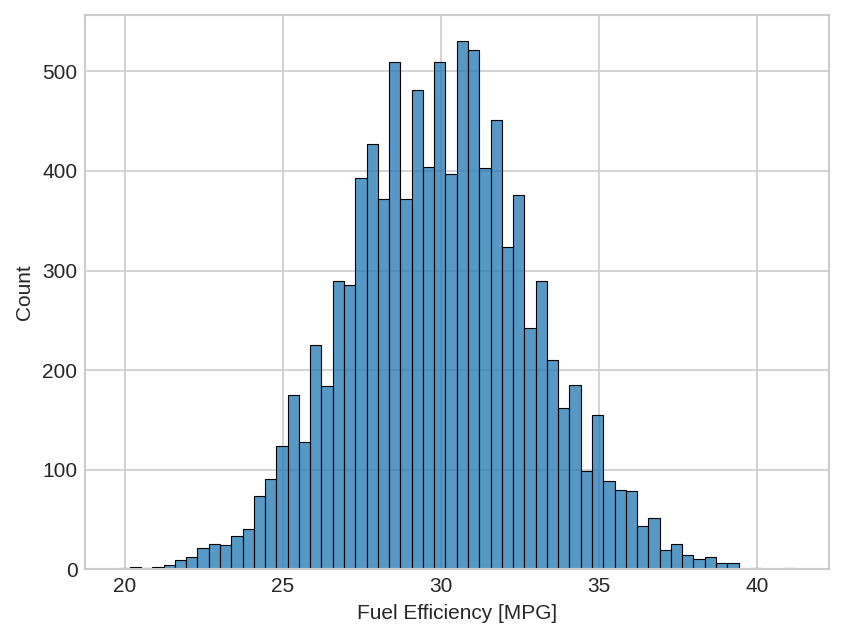

In [22]:
fig = plt.figure(dpi=150)
ax  = fig.add_subplot()
ax  = sns.histplot(data=df, x='fuel_efficiency_mpg', ax=ax)
_   = ax.set_xlabel("Fuel Efficiency [MPG]")

In [23]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [24]:
df['horsepower'].median()

np.float64(254.0)

In [25]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [26]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [27]:
df_train.isnull().sum()

engine_displacement      0
horsepower             538
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [ ]:
df_train_zero = df_train.fillna(0)
X_train_zero = df_train_zero.values[:,:-1]
y_train_zero = df_train_zero.values[:,-1]
w0_zero, w_zero = train_linear_regression(X_train_zero, y_train_zero)

df_train_mean = df_train.fillna(0)
X_train_mean = df_train_zero.values[:,:-1]
y_train_mean = df_train_zero.values[:,-1]
w0_mean, w_mean = train_linear_regression(X_train_mean, y_train_mean)


array([-1.51505520e-03, -4.74024794e-06, -3.95418397e-03,  1.02146785e-01])